In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pymc as pm
import arviz as az
from scipy.integrate import odeint

## Logistic Growth Model

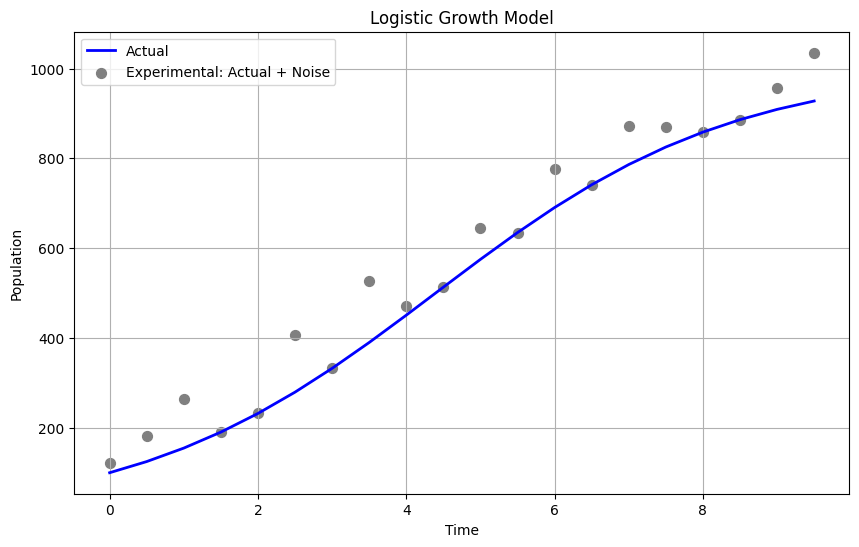

In [138]:
def logistic_model_v2(N0, t, r= 0.5, K = 1000):
    """
    Logistic growth model with parameters defined inside
    """
    N_t = K*N0*np.exp(r*t)/(K+N0*(np.exp(r*t)-1))    
   
    return N_t

# Solve
N0 = 100
t = np.arange(0, 10, 0.5)
N_t_ls = np.array([logistic_model_v2(N0, t_) for t_ in t])

# experimental data by adding noise
N_exp =  N_t_ls + np.random.normal(0,1, len(t)).clip(min=0)*100

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, N_t_ls, 'b-', linewidth=2, label='Actual')
plt.scatter(t,N_exp, label="Experimental: Actual + Noise", color="grey", s=50)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic Growth Model')
plt.grid(True)
plt.show()

In [139]:
## running MCMC for Bayesian parameter estimates
with pm.Model() as model: # define the pymc library environment
    r = pm.HalfNormal("r", sigma = 1) # prior distribution of parameter a
    K = pm.HalfNormal("K",sigma = 500) # prior distribution of parameter b
    
    math_model =  K*N0*np.exp(r*t)/(K+N0*(np.exp(r*t)-1))     # defining the mathematical model (mechanistic model)

    obs = pm.Normal("obs", mu = math_model, sigma = 1, observed = N_exp) # define the type of noise in the observations, commonly Gaussian

    # finding parameter values
    trace = pm.sample(4000, # number of values for each parameter 
                       tune = 1000,  # burn in steps for parameter finding process
                         random_seed = 42, # set the seed to reproduce the results as it is a random process
                         target_accept = 1 # confidence required to accept a parameter 
                         ) 

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, K]
/home/neha/miniconda3/envs/fenicsx_e/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/neha/miniconda3/envs/fenicsx_e/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 25 seconds.


In [140]:
## summary statistics for parameter distribution
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r,0.540,0.000,0.540,0.541,0.000,0.000,3506.0,4450.0,1.0
K,1010.733,0.799,1009.194,1012.201,0.014,0.009,3421.0,4635.0,1.0


array([<Axes: title={'center': 'r'}>, <Axes: title={'center': 'K'}>],
      dtype=object)

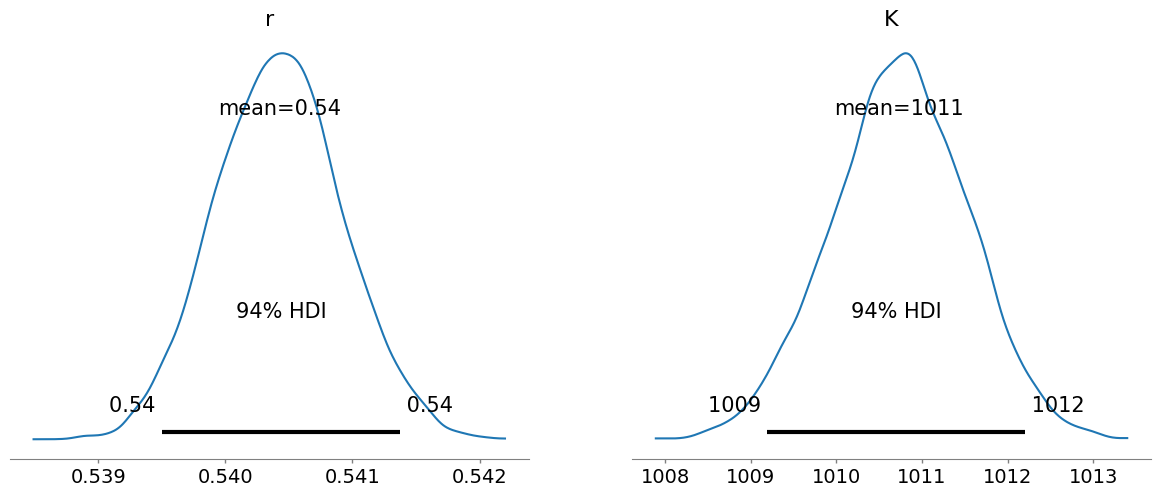

In [141]:
## posterior distribution of two parameters for which prior was a Normal distribution
az.plot_posterior(trace)

Text(0.5, 0.98, 'Posterior parameter distribution for 4 chains')

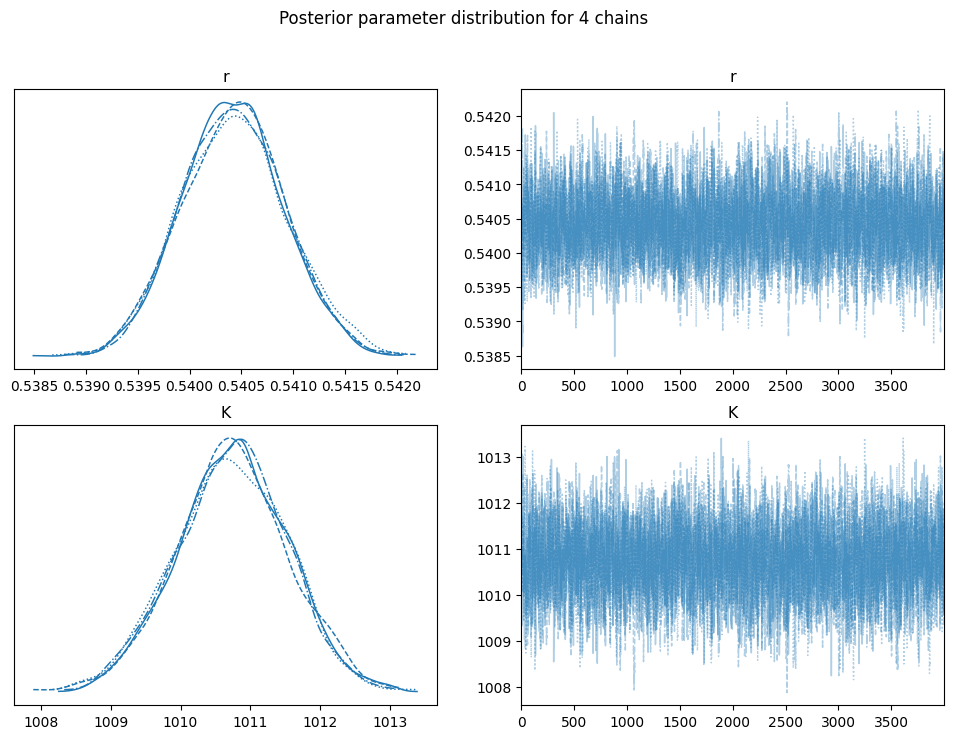

In [142]:
## Posterior parameter distribution for 4 chains (left hand side plots) and 
## parameter sampling sequence by 4 chains (right hand side plots)
az.plot_trace(trace,  figsize=(12, 8))
plt.suptitle("Posterior parameter distribution for 4 chains")

array([[<Axes: >, None],
       [<Axes: xlabel='r', ylabel='K'>, <Axes: >]], dtype=object)

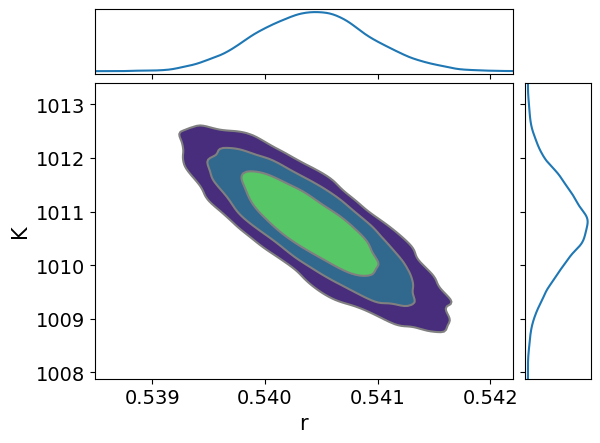

In [143]:
## region of parameter space with high probability to be fit with the data 
az.plot_pair(trace, kind="kde", marginals=True)

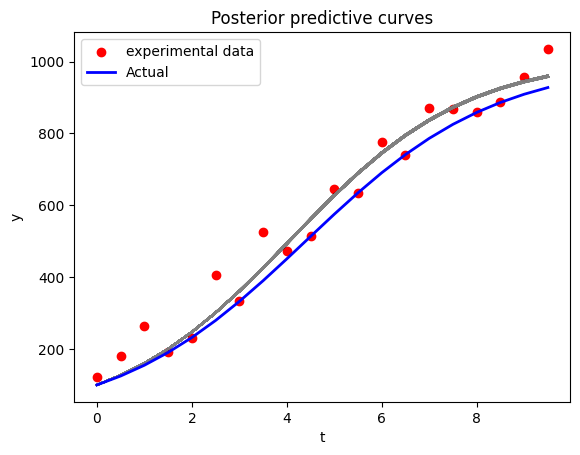

In [148]:
# Extract posterior samples
r_samples = trace.posterior["r"].values.flatten()
K_samples = trace.posterior["K"].values.flatten()

# Plot multiple posterior curves
for i in range(3000):
    r = np.random.choice(r_samples)
    K = np.random.choice(K_samples)
    y =  K*N0*np.exp(r*t)/(K+N0*(np.exp(r*t)-1))  
    plt.plot(t, y, color="gray", alpha=0.1)

# Plot experimental data : actual data + noise
plt.scatter(t, N_exp, color="red", label="experimental data")
plt.plot(t, N_t_ls, 'b-', linewidth=2, label='Actual')

plt.xlabel("t")
plt.ylabel("y")
plt.title("Posterior predictive curves")
plt.legend()
plt.show()